In [ ]:
# Jupyter Notebook for eQTL study


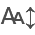

In [3]:
import os
import sys
import scipy
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import scipy.io as sio
import scanpy.external as sce
import matplotlib.pyplot as plt
import gc
import warnings
import re
from itables import init_notebook_mode

warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

init_notebook_mode(all_interactive=True)

sc.settings.verbosity = 4
root_dir = '/Users/darren/Desktop/eQTL_study_2025/'
script_dir = root_dir + 'scripts/'
results_dir = root_dir + 'results/'
data_dir = results_dir + '02PARSE/'
plate1_dir = data_dir + 'combine_plate1/all-sample/DGE_filtered/'
plate2_dir = data_dir + 'combine_plate1/all-sample/DGE_filtered/'
sc.settings.figdir = results_dir + '/figs/'
sys.path.append(script_dir)  # Add the directory containing custom scripts to sys.path

# Adjust Scanpy figure defaults
sc.settings.set_figure_params(dpi=100, fontsize=10, dpi_save=400,
    facecolor = 'white', figsize=(12,6), format='png')


In [ ]:
# Load data

In [4]:
adata_p1 = load_and_dwnsmple_anndata(plate1_dir, 20000)
adata_p2 = load_and_dwnsmple_anndata(plate2_dir, 20000)

In [3]:
# Add prefixes to cell names
adata_p1.obs_names = 'plate1_' + adata_p1.obs_names
adata_p2.obs_names = 'plate2_' + adata_p2.obs_names

# Concatenate the AnnData objects
adata = sc.concat([adata_p1, adata_p2])
adata

AnnData object with n_obs × n_vars = 40000 × 65472
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'leiden'
    obsm: 'X_pca', 'X_umap'
    layers: 'norm10k'

In [4]:
adata.obs

sample species  gene_count  tscp_count  \
bc_wells                                                             
plate1_68_81_62__s12    17883_Hipp    hg38         867        1121   
plate1_21_24_03__s4   sample_15070    hg38        2100        3693   
plate1_39_81_10__s2      17804_WGE    hg38        1691        2537   
plate1_46_22_05__s11  sample_18372    hg38        5335       12273   
plate1_44_11_09__s13  sample_17048    hg38        1137        1794   
...                            ...     ...         ...         ...   
plate2_41_42_85__s2   sample_12047    hg38        7367       29317   
plate2_60_19_57__s9   sample_11928    hg38        3955        9134   
plate2_67_05_93__s10      17883_FC    hg38        8932       41564   
plate2_02_44_15__s7     14493_Thal    hg38        2227        4010   
plate2_77_85_03__s9   sample_17086    hg38         683         840   

                      mread_count leiden  
bc_wells                                  
plate1_68_81_62__s12         2371     19  
plate1_21_24_03__s4          7152     20  
plate1_39_81_10__s2          7029     15  
plate1_46_22_05__s11        25614     14  
plate1_44_11_09__s13         3291      4  
...                           ...    ...  
plate2_41_42_85__s2         85272     18  
plate2_60_19_57__s9         18651      0  
plate2_67_05_93__s10        85883      0  
plate2_02_44_15__s7          7613      5  
plate2_77_85_03__s9          1551     12  

[40000 rows x 6 columns]

In [ ]:
# Clean metadata

In [12]:
adata.obs['sample'] = adata.obs['sample'].str.replace('sample_', '') 
adata.obs['plate'] = adata.obs.index.str.split('_').str[0]
adata = adata[~adata.obs['sample'].str.endswith(tuple(['WGE', 'Hipp', 'Thal']))]
adata.var.index = adata.var.index.str.replace('_hg38', '') 
adata.obs['sample'].value_counts()

sample
18372       1043
11654        946
17053        826
17048        809
17936        763
            ... 
14483_FC     254
14611_FC     177
14402        153
17940        132
14521        123
Name: count, Length: 73, dtype: int64

In [ ]:
# Initial QC

In [ ]:
# adata.var["mt"] = adata.var_names.str.startswith("MT-")
# adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
# sc.pp.calculate_qc_metrics(
#     adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
# )

# #sc.pl.violin(
# #    plate1_adata,
# #    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
# #    jitter=0.4,
# #    multi_panel=True,
# #)

# adata.obs

# sc.pl.violin(adata, 'total_counts', jitter=0.4, groupby = 'sample', rotation = 90, size=1.5)

# Step 1: Calculate the MAD and threshold
# Group by the 'sample' column and calculate median and MAD for each group
# grouped_stats = adata.obs.groupby('sample')['total_counts'].agg(['median'])
# grouped_stats
# # # Define a function to calculate MAD for a given series
# def mad_per_sample(series):
#     median = np.median(series)
#     return np.median(np.abs(series - median))

# # Group by 'sample' and calculate median and MAD
# grouped_stats = adata.obs.groupby('sample')['total_counts'].agg(['median'])
# adata.obs.groupby('sample')['total_counts'].transform(mad_per_sample)

# # Calculate MAD threshold, lower bound, and upper bound for each sample
# grouped_stats['mad_threshold'] = 3 * grouped_stats['mad']
# grouped_stats['lower_bound'] = grouped_stats['median'] - grouped_stats['mad_threshold']
# grouped_stats['upper_bound'] = grouped_stats['median'] + grouped_stats['mad_threshold']

# # Flag outliers for each sample
# adata.obs['is_outlier_per_sample'] = adata.obs.apply(
#     lambda row: (row['total_counts'] < grouped_stats.loc[row['sample'], 'lower_bound']) | 
#                 (row['total_counts'] > grouped_stats.loc[row['sample'], 'upper_bound']),
#     axis=1
# )
# grouped_stats

# # Create the violin plot
# fig, ax = plt.subplots(figsize=(10, 6))
# sc.pl.violin(
#     adata,
#     keys='total_counts',
#     jitter=0.4,
#     groupby='sample',
#     rotation=90,
#     size=1.5,
#     ax=ax,
#     show=False
# )

# # Overlay outlier cells with red dots
# outliers = adata.obs.loc[adata.obs['is_outlier']]
# ax.scatter(
#     x=outliers['sample'],  # X-coordinates (groupby value)
#     y=outliers['total_counts'],  # Y-coordinates (outlier values)
#     color='red',
#     label='Outliers',
#     s=10,
#     alpha=0.8
# )

# # Add legend and show plot
# ax.legend()
# plt.tight_layout()
# plt.show()
# grouped_stats
# plt.hist(adata.obs['total_counts'], bins=1000)
# plt.xlabel('Total counts')
# plt.ylabel('N cells')
# plt.axvline(50000, color='red')

# plt.hist(adata.obs['n_genes_by_counts'], bins=100)
# plt.xlabel('N genes')
# plt.ylabel('N cells')
# plt.axvline(1000, color='red')

plt.hist(adata.var['n_cells_by_counts'], bins=500)
plt.xlabel('N cells expressing > 0')
plt.ylabel('log(N genes)') # for visual clarity
plt.axvline(2, color='red')
plt.yscale('log') 

sns.jointplot(
    data=adata.obs,
    x="log1p_total_counts",
    y="log1p_n_genes_by_counts",
    kind="hex",
)


/var/folders/_p/8rdhs_nn40j2s519974zb9ph0000gn/T/ipykernel_1779/3500998848.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs['is_outlier'] = adata.obs.groupby('sample')['total_counts'].transform(


AttributeError: 'Series' object has no attribute 'value_count'

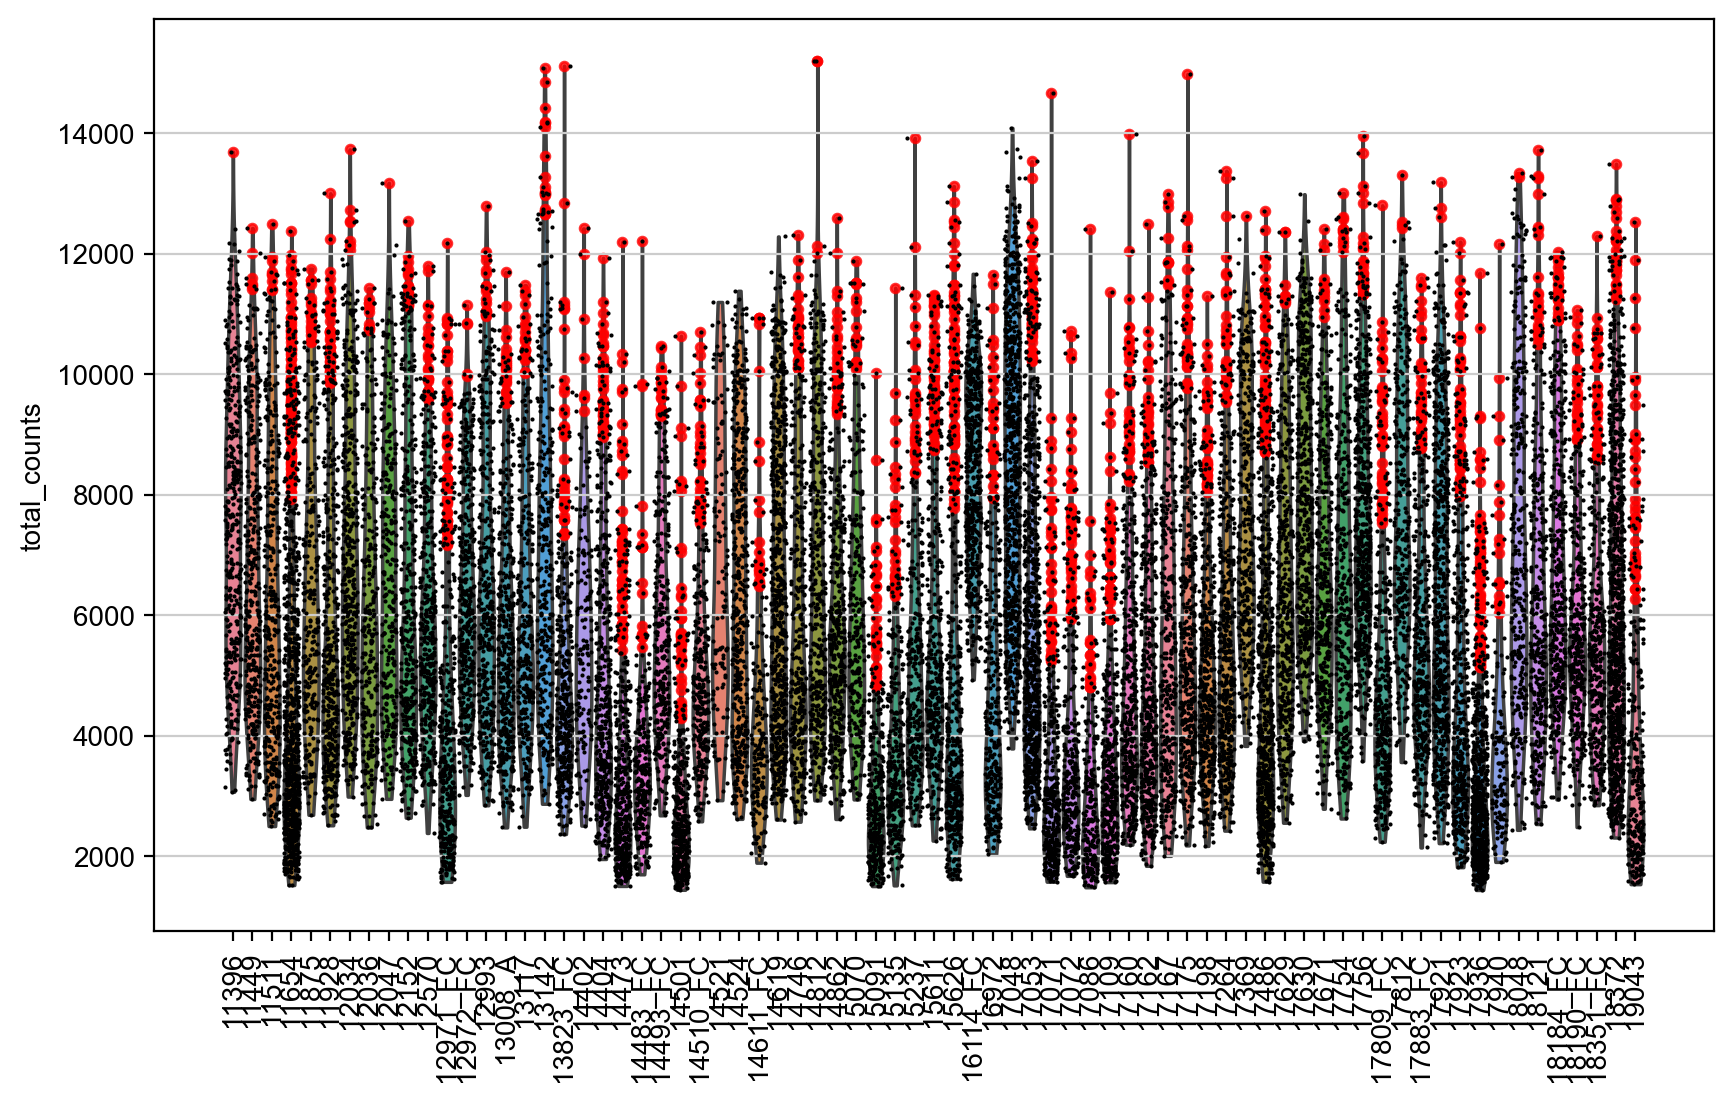

In [117]:
def is_outlier(data, threshold=3, log=False, use_median=True):
    """
    Mimics scuttle::isOutlier to detect outliers in a dataset.
    
    Parameters:
    - data: A pandas Series or numpy array containing numeric values.
    - threshold: Number of MADs or standard deviations to define outliers.
    - log: Whether to log-transform the data before analysis.
    - use_median: If True, use median and MAD; otherwise, use mean and standard deviation.
    
    Returns:
    - A boolean array marking outliers.
    """
    if log:
        data = np.log1p(data)
    
    if use_median:
        center = np.median(data)
        deviation = np.median(np.abs(data - center))  # MAD
    else:
        center = np.mean(data)
        deviation = np.std(data)  # Standard deviation
    
    lower_bound = center - threshold * deviation
    upper_bound = center + threshold * deviation
    
    return (data < lower_bound) | (data > upper_bound)

# Apply the function per sample
adata.obs['is_outlier'] = adata.obs.groupby('sample')['total_counts'].transform(
    lambda x: is_outlier(x, threshold=3, log=False, use_median=True)
)

# View the results
adata.obs[['sample', 'total_counts', 'is_outlier']].head()

# Create the violin plot
fig, ax = plt.subplots(figsize=(10, 6))
sc.pl.violin(
    adata,
    keys='total_counts',
    jitter=0.4,
    groupby='sample',
    rotation=90,
    size=1.5,
    ax=ax,
    show=False
)

# Overlay outlier cells with red dots
outliers = adata.obs.loc[adata.obs['is_outlier']]
ax.scatter(
    x=outliers['sample'],  # X-coordinates (groupby value)
    y=outliers['total_counts'],  # Y-coordinates (outlier values)
    color='red',
    label='Outliers',
    s=10,
    alpha=0.8
)
adata.obs['is_outlier'].value_counts()

In [99]:
# Pre-filter counts
cells_per_sample = adata.obs['sample'].value_counts().reset_index(name='cell_count')
median_tscp_per_sample = adata.obs.groupby('sample')['tscp_count'].median().reset_index(name='median_tscp_count')
median_gene_per_sample = adata.obs.groupby('sample')['gene_count'].median().reset_index(name='median_gene_count')

# Join the DataFrames
merged_df = pd.merge(cells_per_sample, median_tscp_per_sample, on='sample')
merged_df = pd.merge(merged_df, median_gene_per_sample, on='sample')

print(merged_df)

      sample  cell_count  median_tscp_count  median_gene_count
0      18372        1089             2750.0             1772.0
1      11654         995             1374.0              981.0
2      17048         847             8001.0             3449.0
3      17053         807             2432.0             1555.0
4      17486         793             1486.0             1069.0
..       ...         ...                ...                ...
68     15070         233             2904.0             1717.0
69     14402         164             2290.0             1571.0
70  14611_FC         155             1578.0             1035.0
71     17940         137             1101.0              845.0
72     14521         117             4220.0             2374.0

[73 rows x 4 columns]


/var/folders/_p/8rdhs_nn40j2s519974zb9ph0000gn/T/ipykernel_6282/1006752915.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_tscp_per_sample = adata.obs.groupby('sample')['tscp_count'].median().reset_index(name='median_tscp_count')
/var/folders/_p/8rdhs_nn40j2s519974zb9ph0000gn/T/ipykernel_6282/1006752915.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_gene_per_sample = adata.obs.groupby('sample')['gene_count'].median().reset_index(name='median_gene_count')


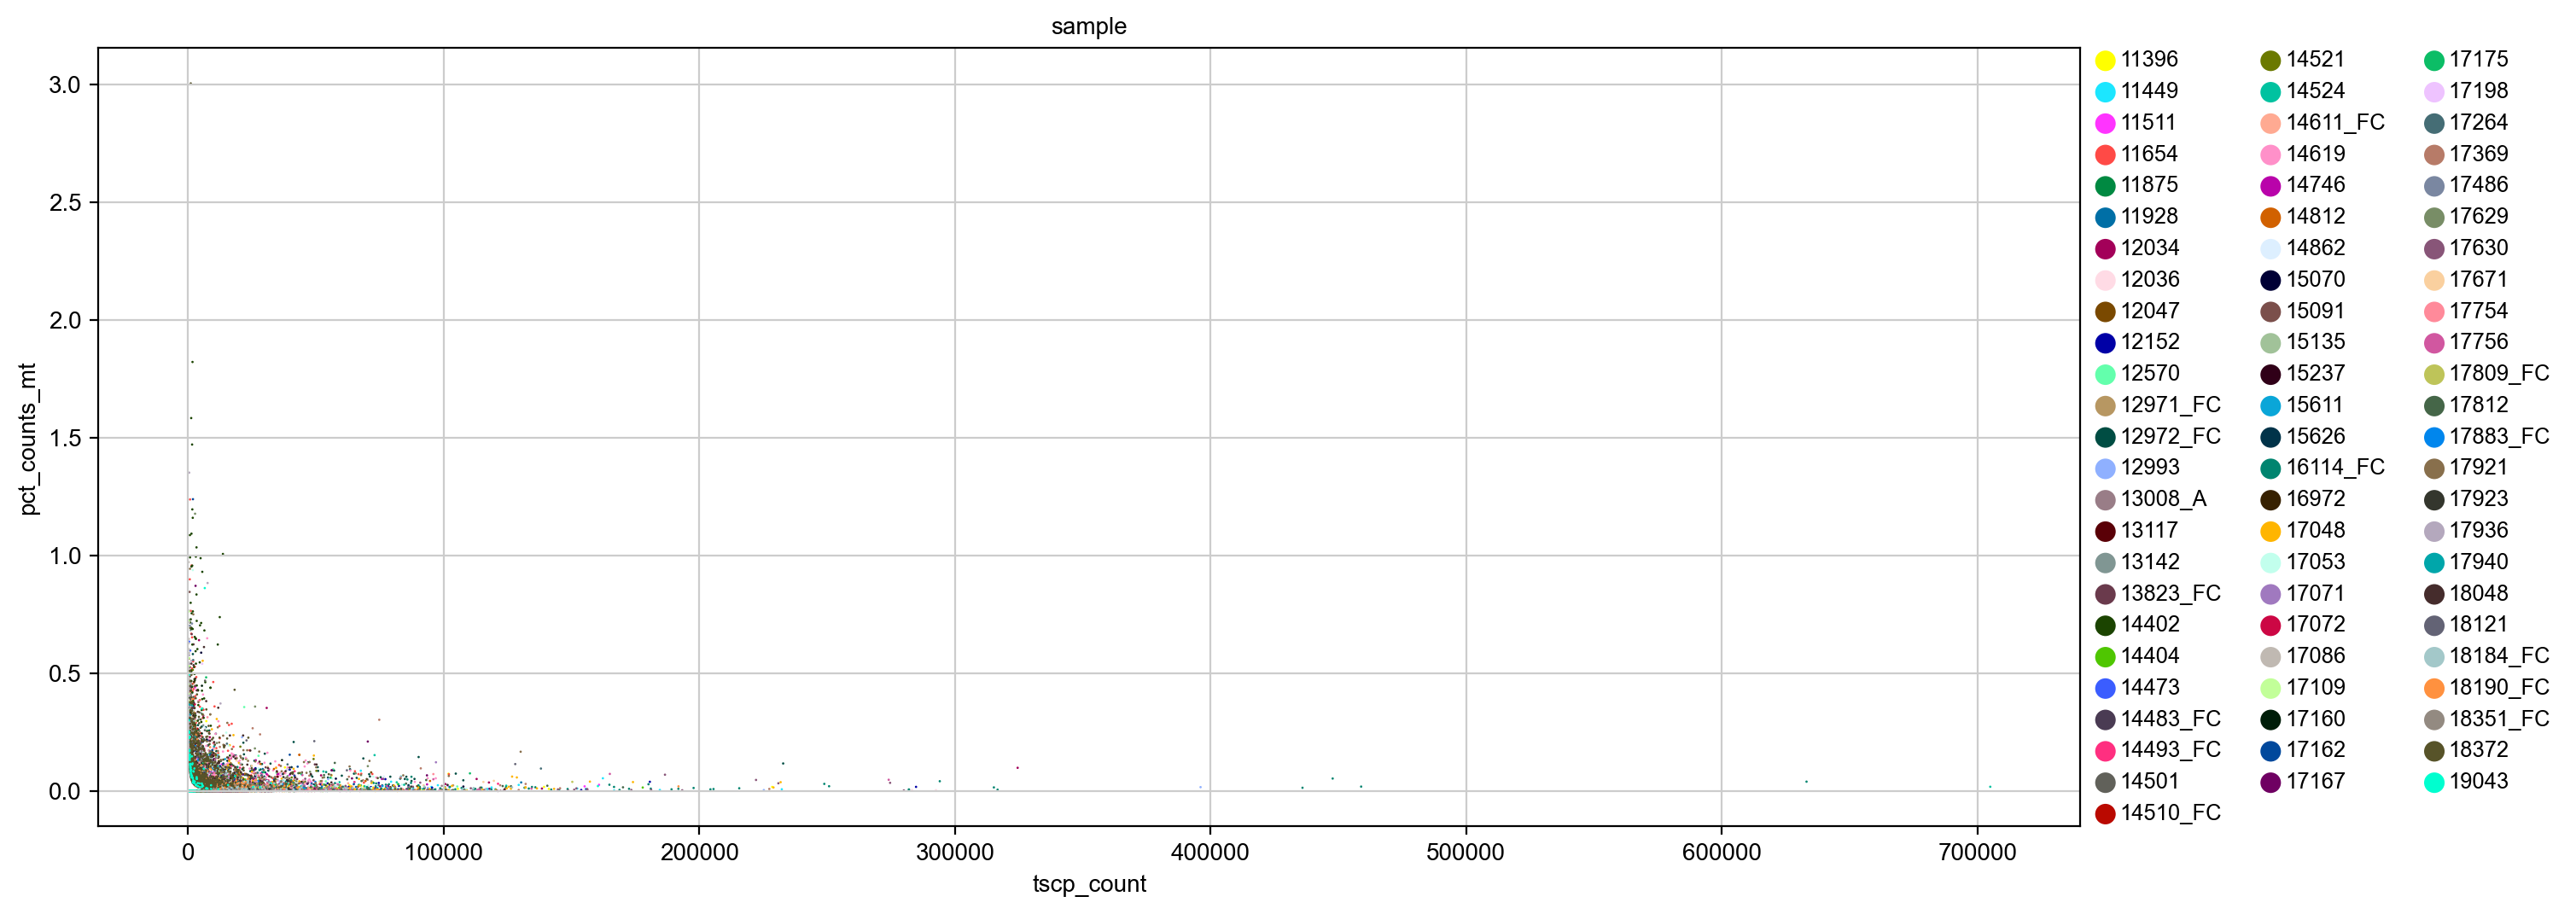

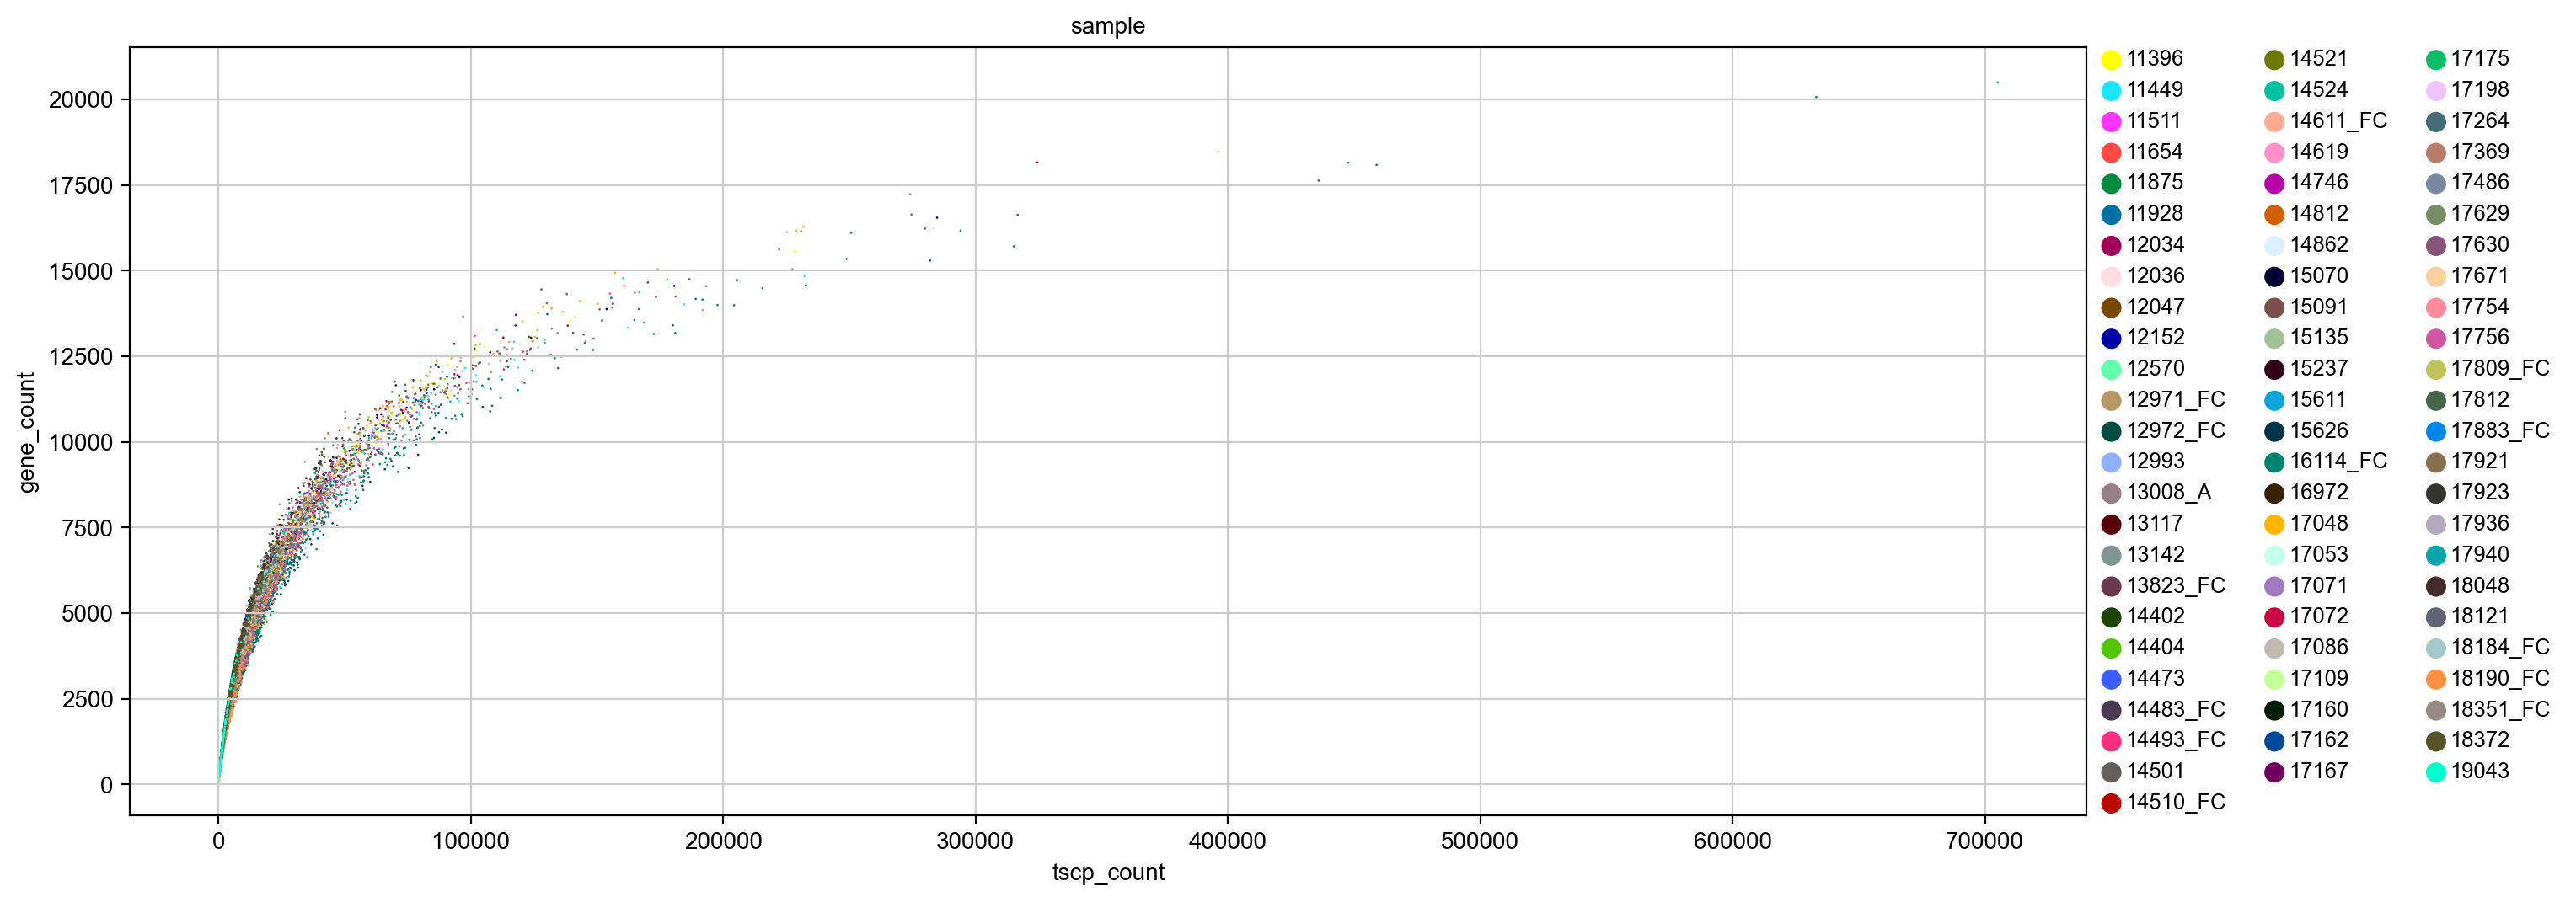

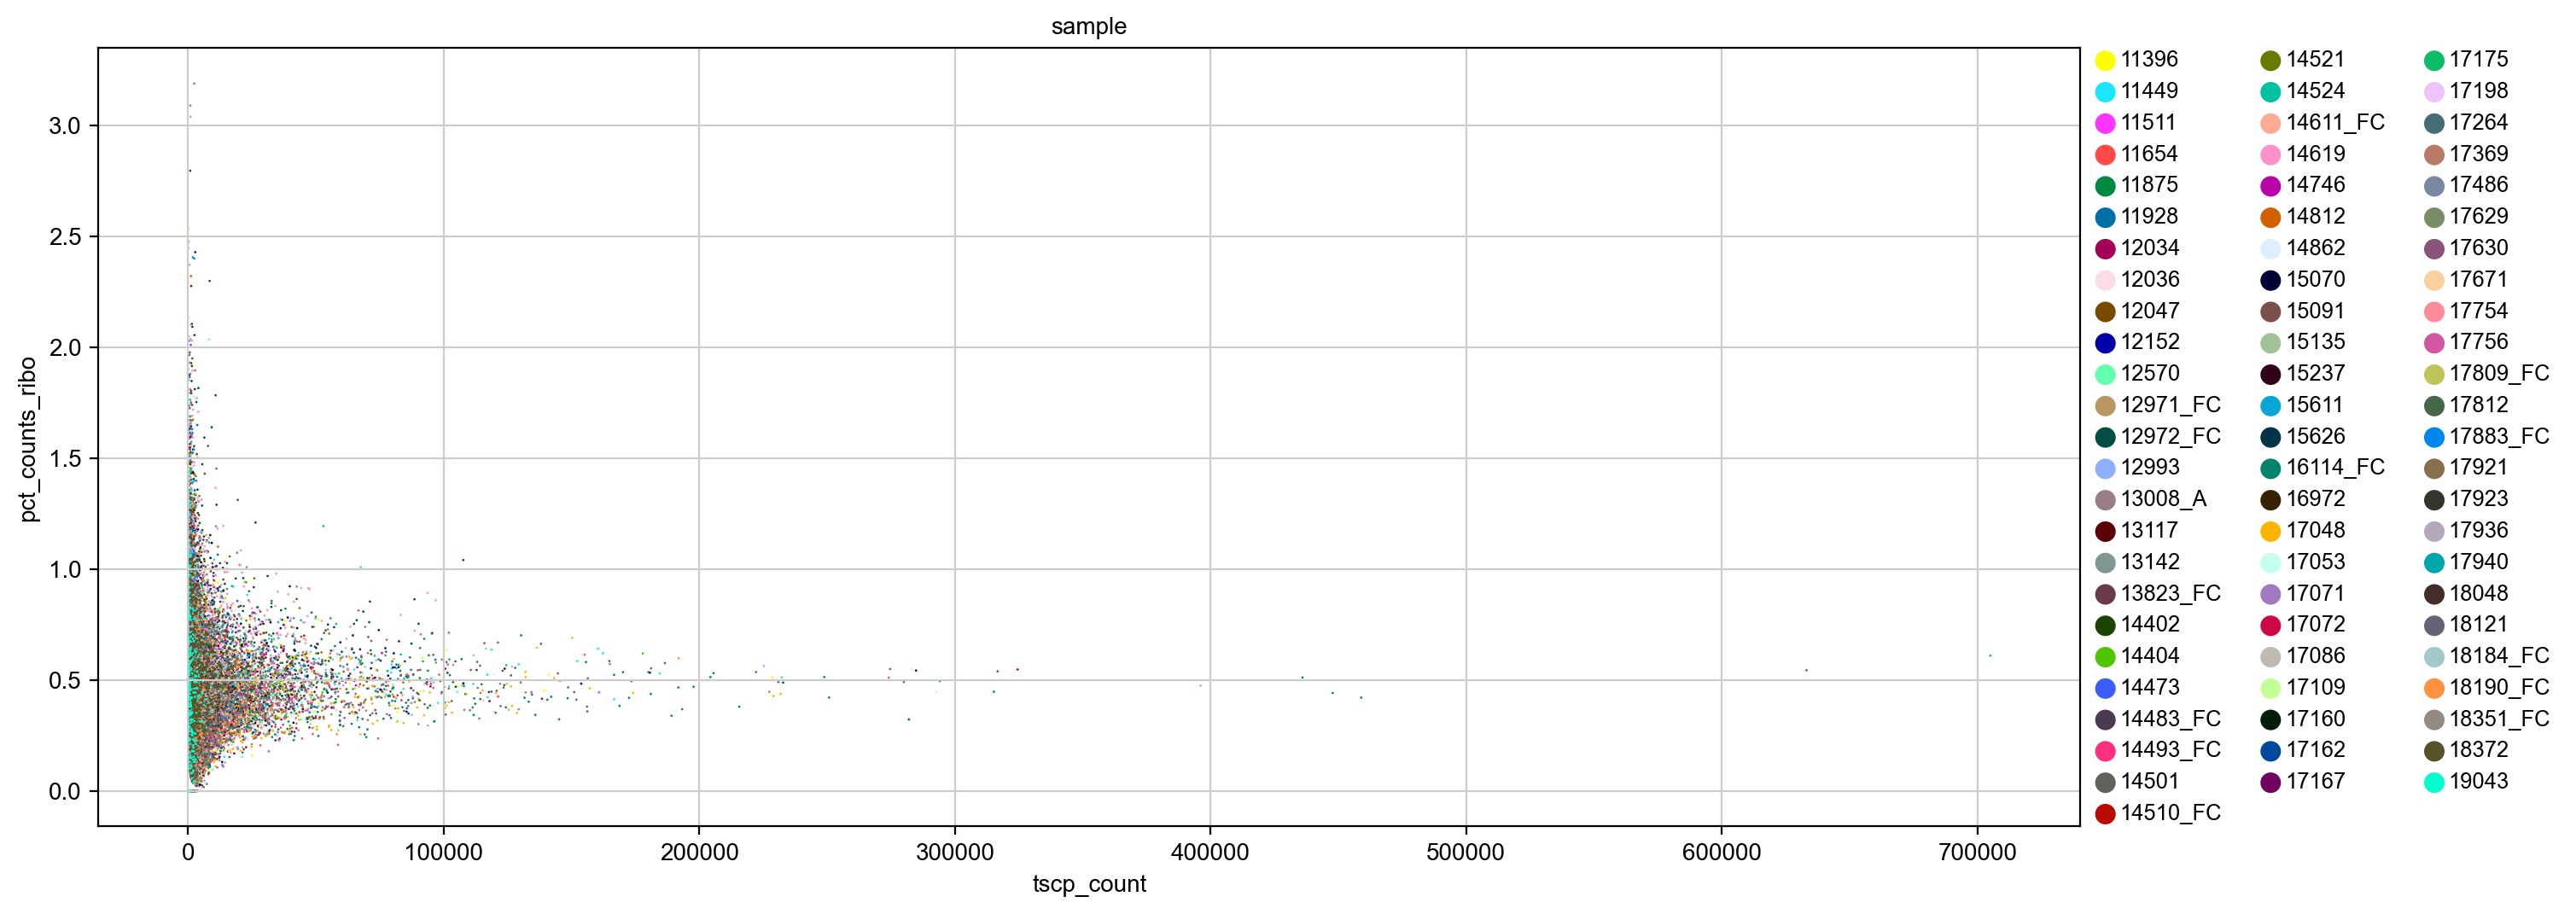

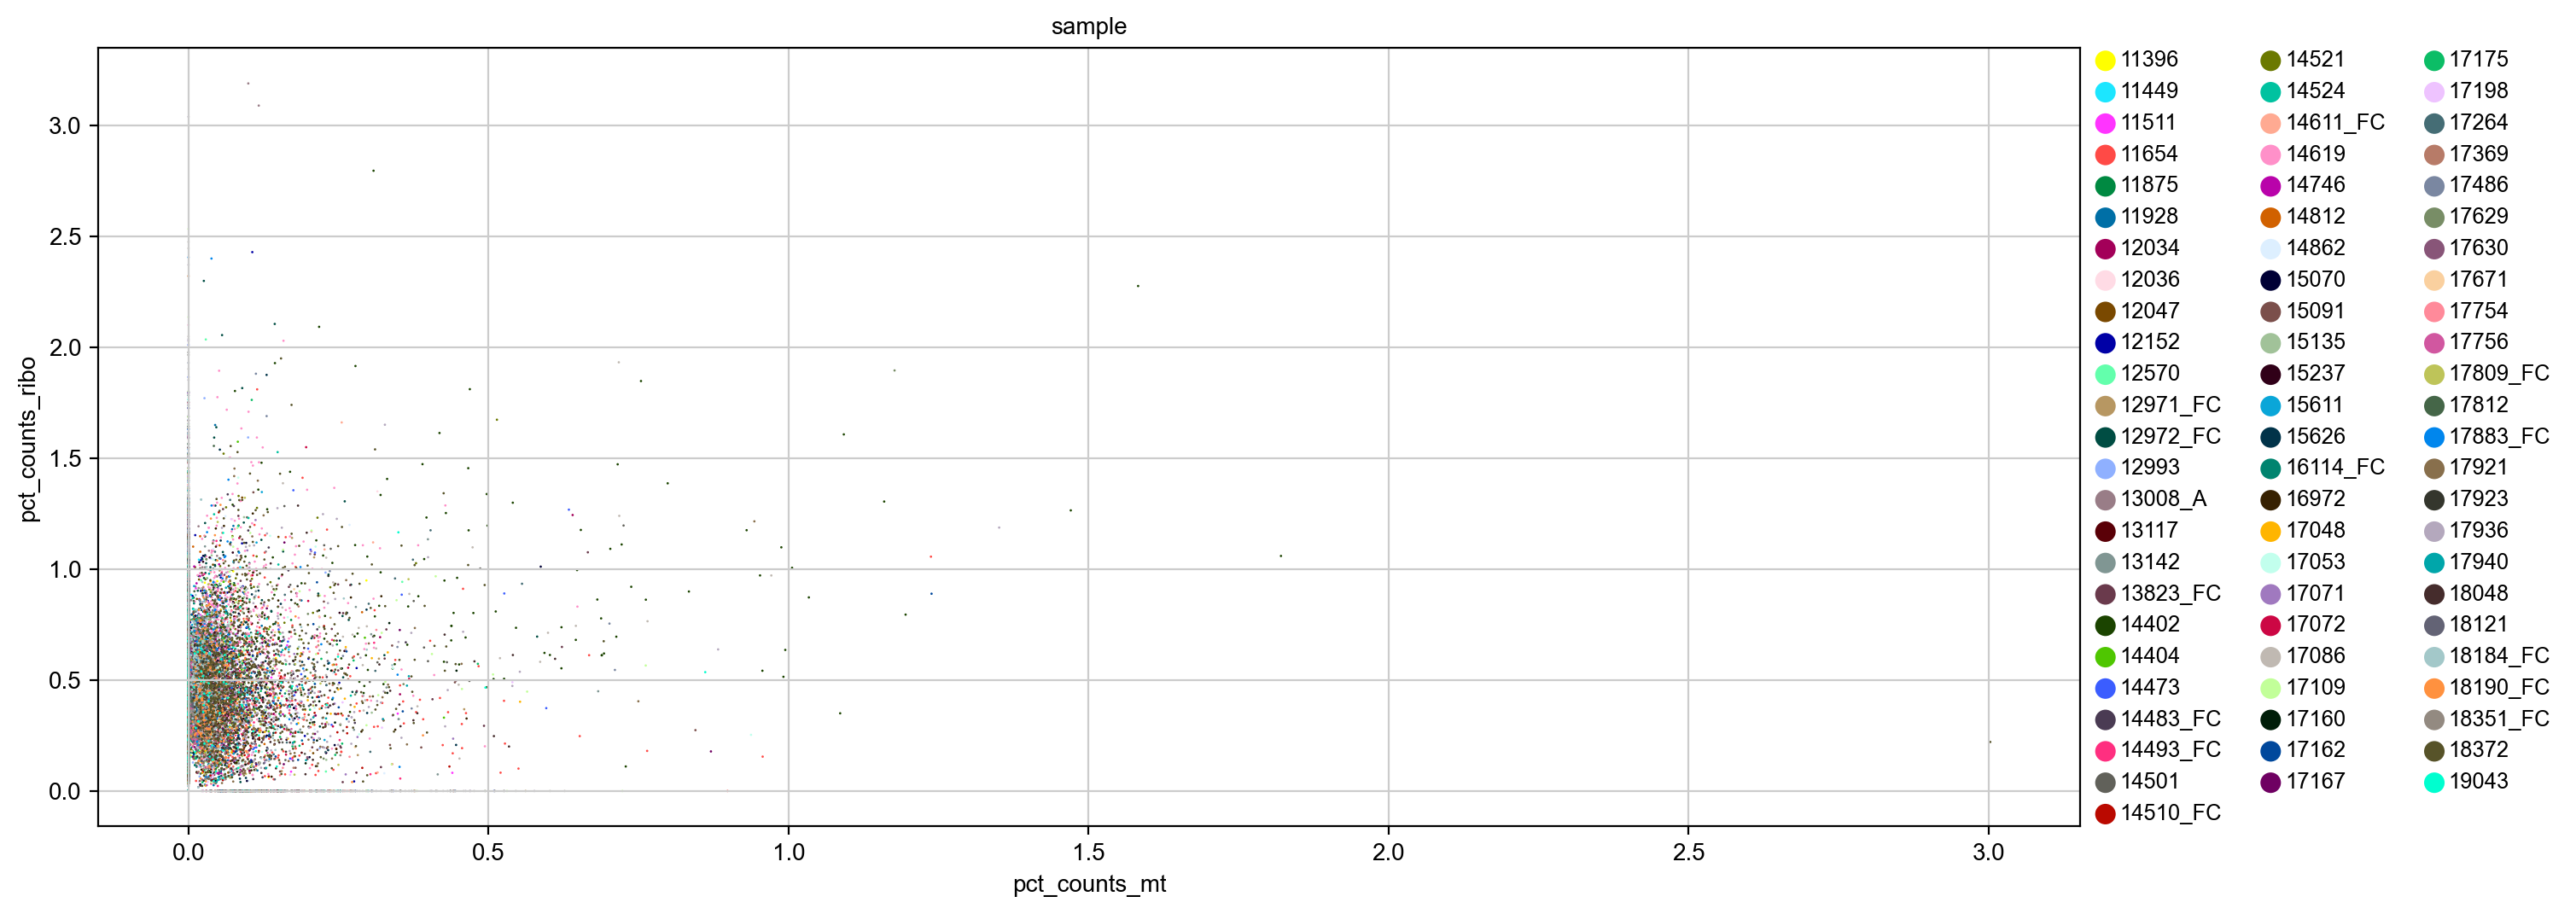

In [24]:
sc.pl.scatter(adata, x='tscp_count', y='pct_counts_mt', color="sample")
sc.pl.scatter(adata, x='tscp_count', y='gene_count', color="sample")
sc.pl.scatter(adata, x='tscp_count', y='pct_counts_ribo', color="sample")
sc.pl.scatter(adata, x='pct_counts_mt', y='pct_counts_ribo', color="sample")

normalizing counts per cell
    finished (0:00:00)


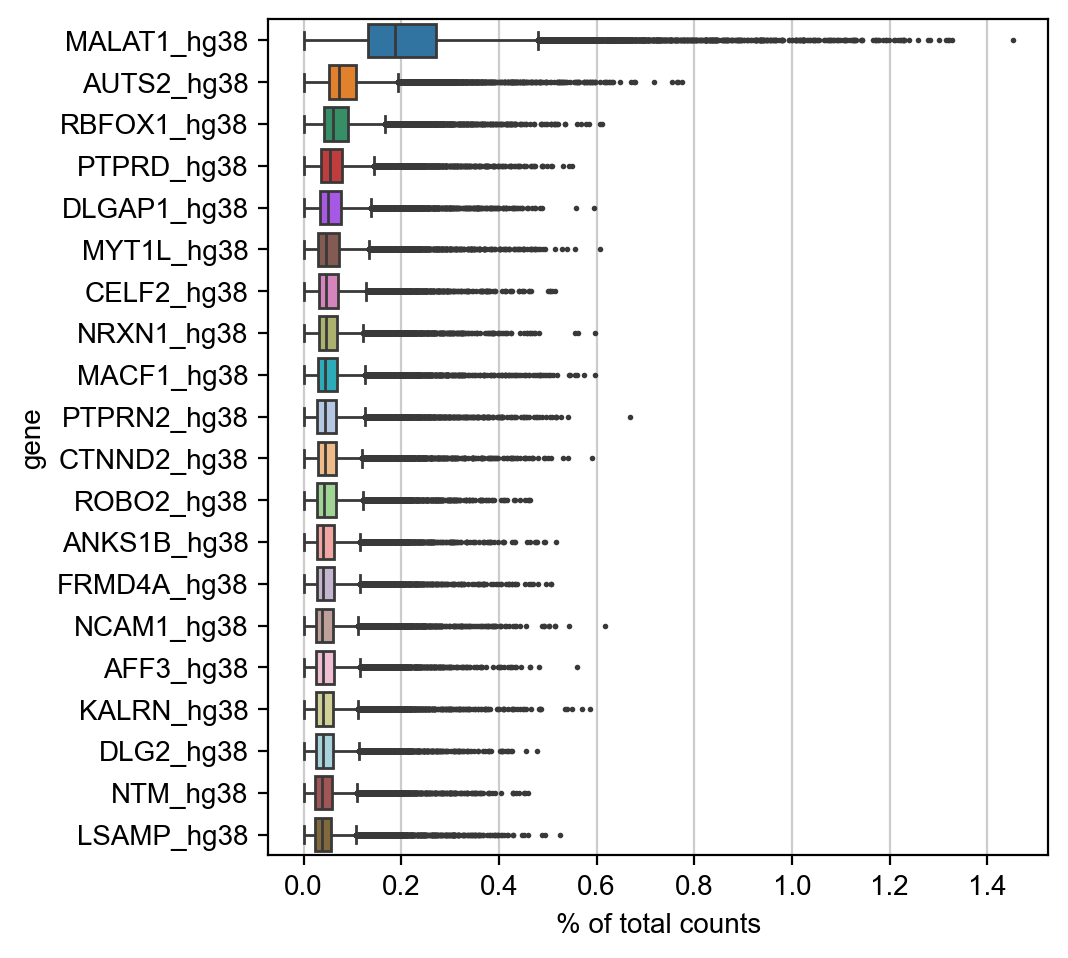

In [14]:
sc.pl.highest_expr_genes(adata, n_top=20)

In [21]:

adata.var

mt   ribo     hb  n_cells_by_counts  mean_counts  \
gene                                                                   
TSPAN6           False  False  False                449     0.073068   
TNMD             False  False  False                 26     0.006848   
DPM1             False  False  False               3613     0.283605   
SCYL3            False  False  False               2407     0.224039   
FIRRM            False  False  False               2900     0.245581   
...                ...    ...    ...                ...          ...   
ENSG00000310533  False  False  False                 86     0.017957   
ENSG00000310534  False  False  False                 12     0.003702   
ENSG00000310535  False  False  False                  0     0.000000   
ENSG00000310537  False  False  False                 12     0.003325   
DDX11L2-2        False  False  False                 19     0.004432   

                 log1p_mean_counts  pct_dropout_by_counts  total_counts  \
gene                                                                      
TSPAN6                    0.070522              98.581000   2312.020013   
TNMD                      0.006824              99.917831    216.673627   
DPM1                      0.249672              88.581632   8973.821458   
SCYL3                     0.202156              92.393022   7089.041467   
FIRRM                     0.219602              90.834966   7770.666292   
...                            ...                    ...           ...   
ENSG00000310533           0.017798              99.728209    568.204191   
ENSG00000310534           0.003696              99.962076    117.150328   
ENSG00000310535           0.000000             100.000000      0.000000   
ENSG00000310537           0.003320              99.962076    105.218876   
DDX11L2-2                 0.004422              99.939953    140.239307   

                 log1p_total_counts  
gene                                 
TSPAN6                     7.746309  
TNMD                       5.382997  
DPM1                       9.102178  
SCYL3                      8.866446  
FIRRM                      8.958240  
...                             ...  
ENSG00000310533            6.344239  
ENSG00000310534            4.771958  
ENSG00000310535            0.000000  
ENSG00000310537            4.665502  
DDX11L2-2                  4.950456  

[65472 rows x 9 columns]

In [ ]:
# Filter 1: JB; rem nuc < 300 genes & 500 reads; rm samps < 500 cells

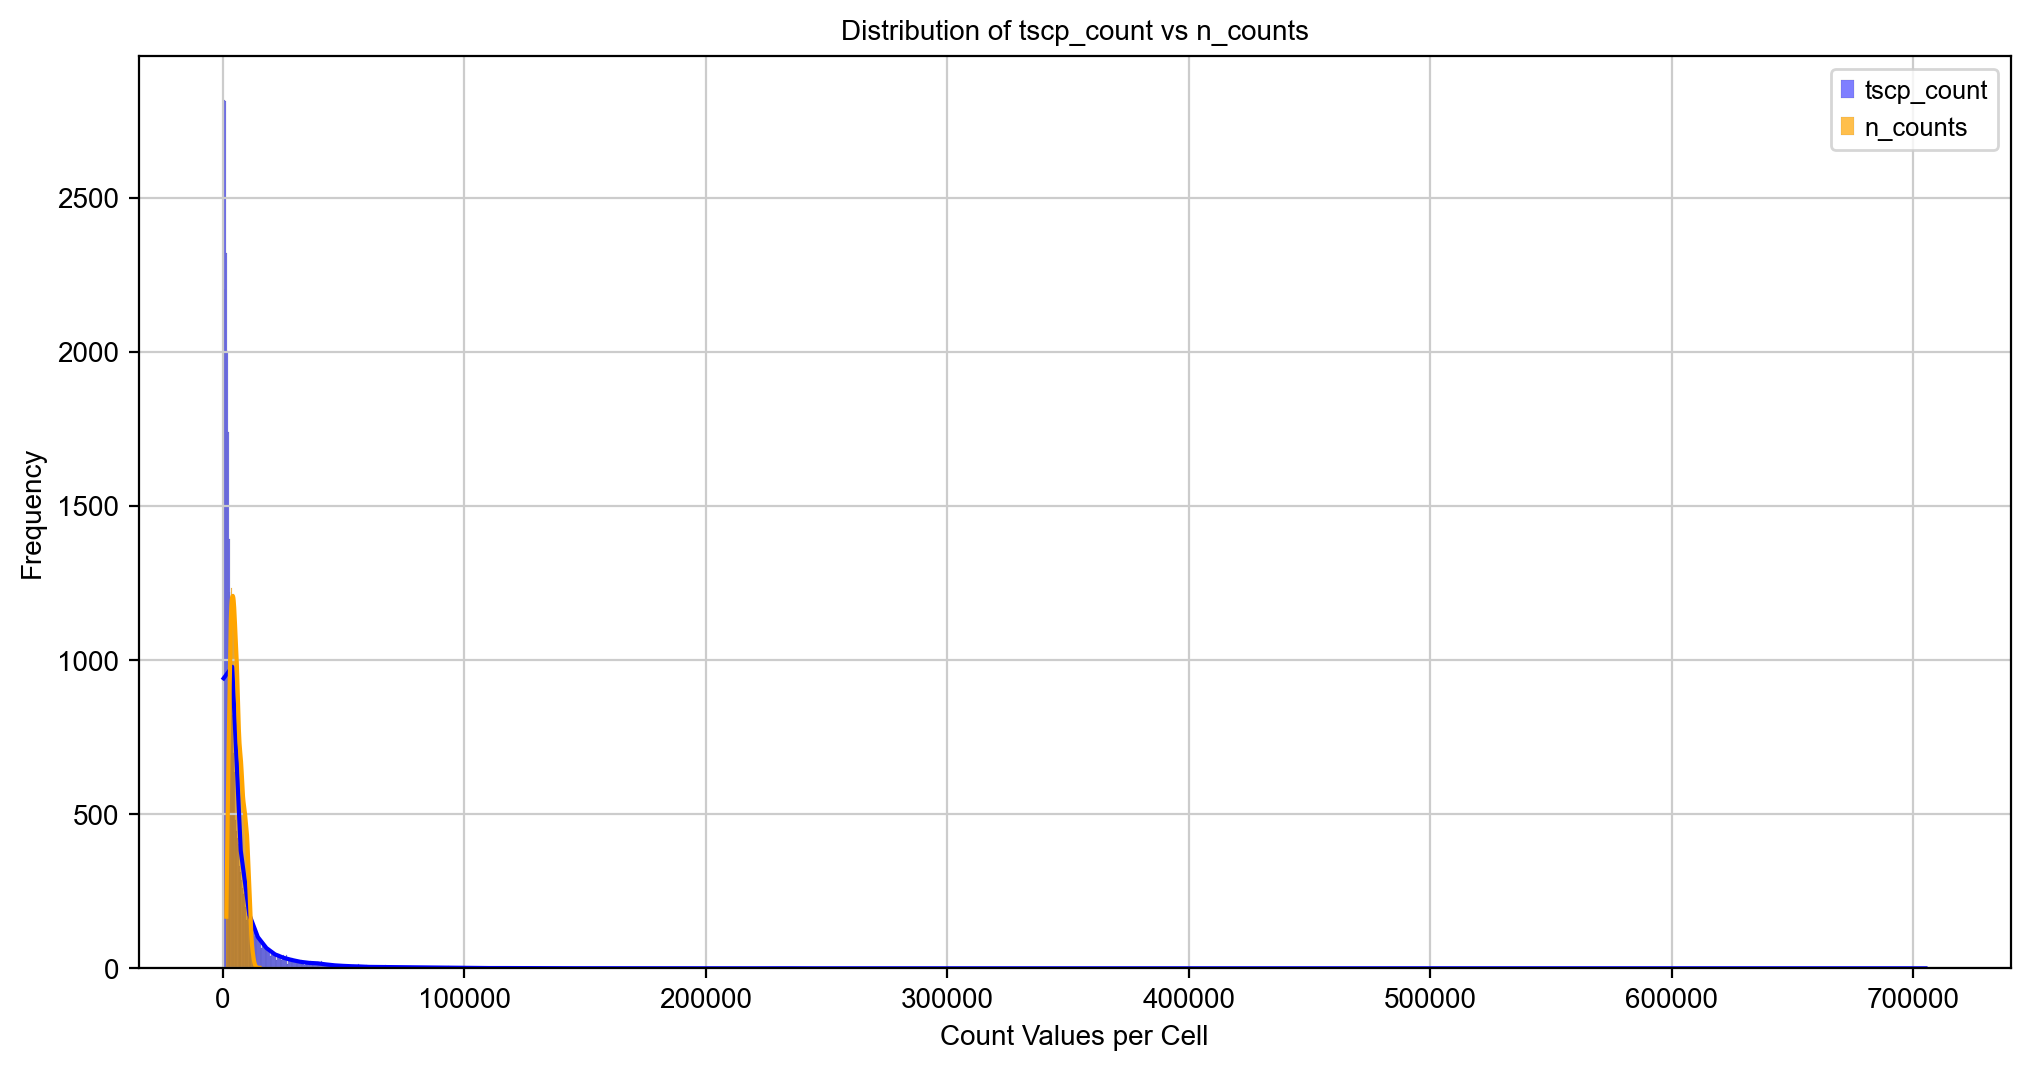

In [31]:
#sc.pp.filter_cells(adata, min_genes=300 )
#sc.pp.filter_cells(adata, min_counts = 500)
#sc.pp.filter_genes(adata, min_cells=3)

#print(adata.n_obs, adata.n_vars)
#adata.obs['n_counts'] = adata.X.sum(axis=1).A1 if scipy.sparse.issparse(adata.X) else adata.X.sum(axis=1)
adata.obs
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(adata.obs['tscp_count'], kde=True, color="blue", label="tscp_count")
sns.histplot(adata.obs['n_counts'], kde=True, color="orange", label="n_counts", alpha=0.7)
plt.legend()
plt.xlabel("Count Values per Cell")
plt.ylabel("Frequency")
plt.title("Distribution of tscp_count vs n_counts")
plt.show()

In [ ]:
# Check cells counts after filtering before assigning
adata[(adata.obs.pct_counts_mt < 25) & 
(adata.obs.n_genes_by_counts < 5000) & 
(adata.obs.total_counts < 25000),:].shape

# Do the filtering
adata = adata[(adata.obs.pct_counts_mt < 25) & 
(adata.obs.n_genes_by_counts < 5000) & 
(adata.obs.total_counts < 25000),:]

In [ ]:
# Normalise

In [32]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:00)


In [ ]:
# ID highly variable genes

In [33]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.25)
# This saves the original set of genes 
adata.raw = adata

adata = adata[:,adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)

extracting highly variable genes
    Gene indices [ 1411 10009 26118] fell into a single bin: their normalized dispersion was set to 1.
    Decreasing `n_bins` will likely avoid this effect.
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


/Users/darren/miniconda/envs/eqtl_study/lib/python3.12/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
    ... clipping at max_value 10


In [ ]:
# PCA

computing PCA
    with n_comps=50
    finished (0:02:05)
    and added
    'X_pca', the PCA coordinates (adata.obs)
    'PCs', the loadings (adata.varm)
    'pca_variance', the variance / eigenvalues (adata.uns['pca'])
    'pca_variance_ratio', the variance ratio (adata.uns['pca'])


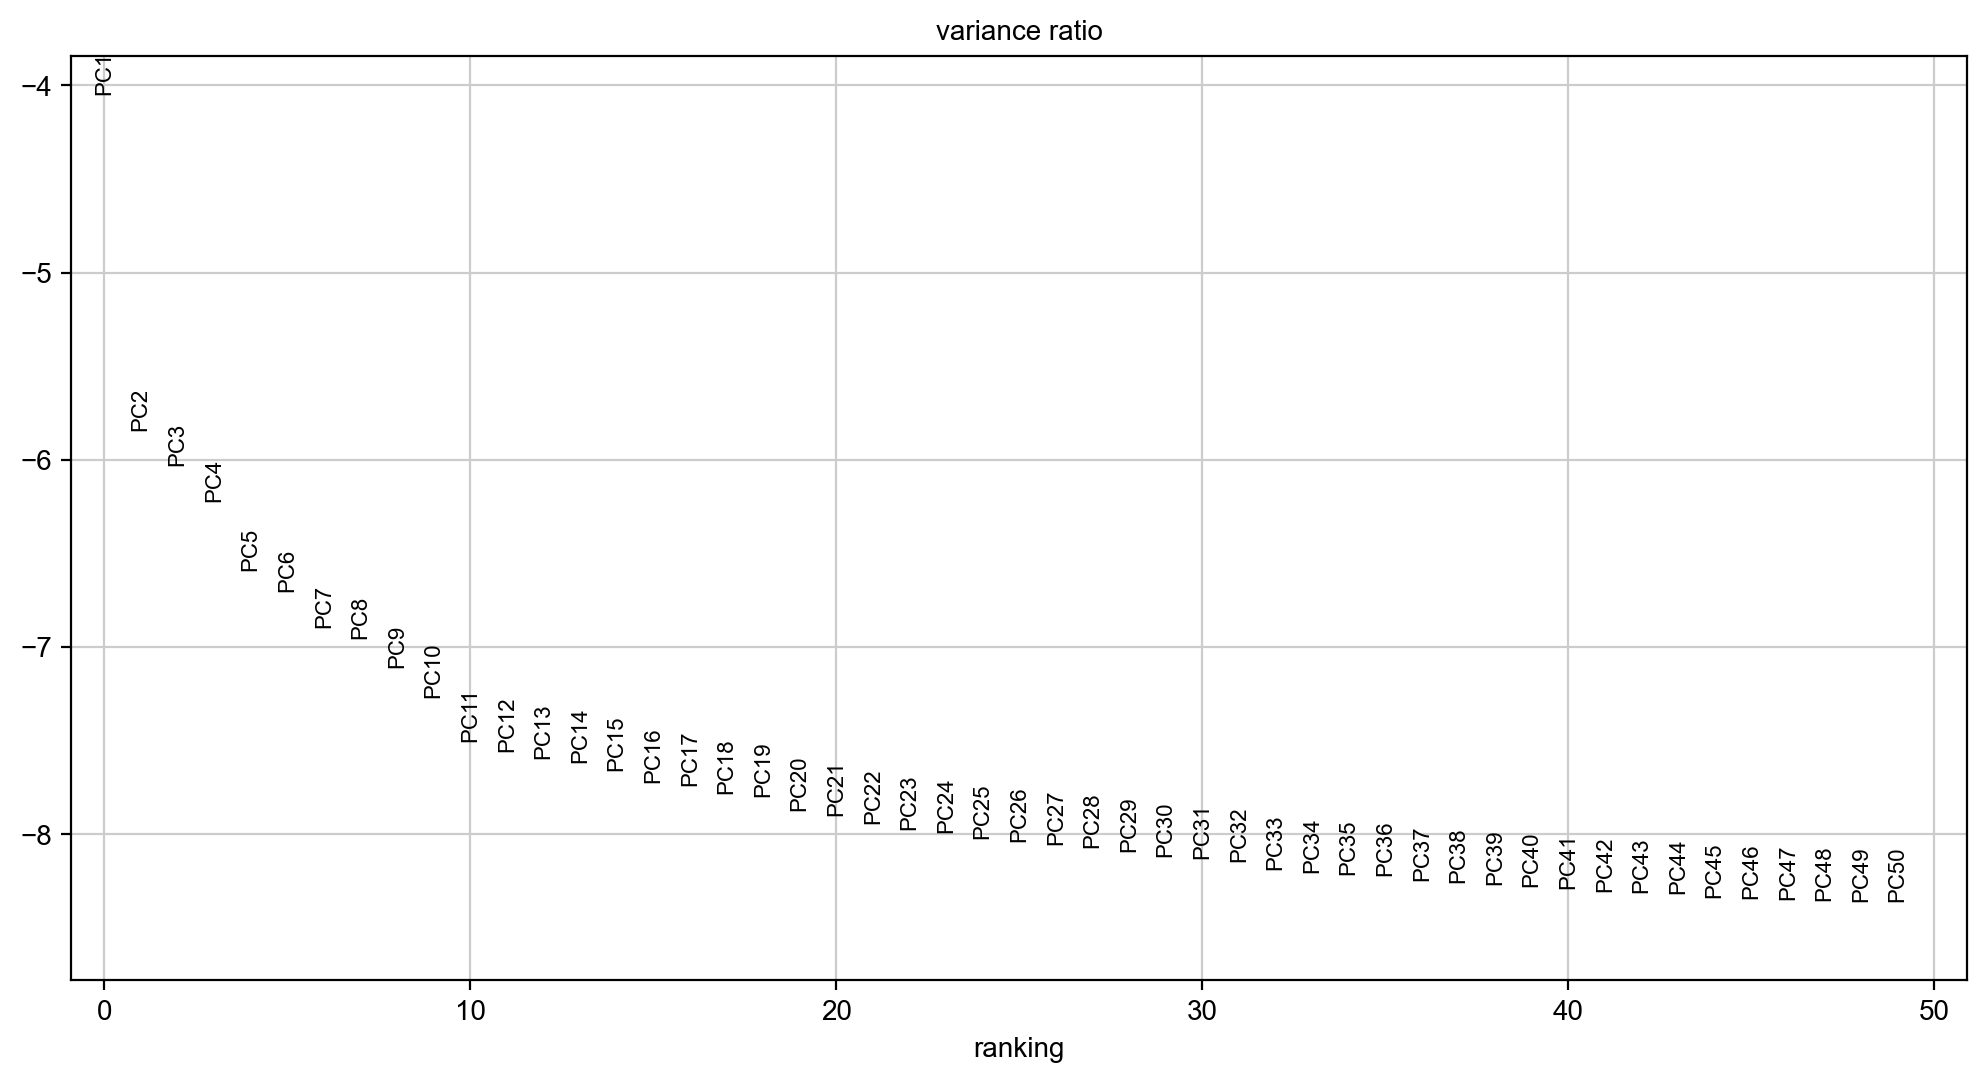

In [34]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50, save='') # scanpy generates the filename automatically

In [ ]:
# UMAP and Clustering

In [37]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=50)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)

computing neighbors
    computing neighbors
    using 'X_pca' with n_pcs = 50
    computed neighbors (0:00:29)
    computed connectivities (0:00:05)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:34)
computing UMAP


  0%|          | 0/200 [00:00<?, ?it/s]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:14)
running Leiden clustering


/var/folders/_p/8rdhs_nn40j2s519974zb9ph0000gn/T/ipykernel_1779/2331113366.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


    finished: found 18 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:03)


In [102]:
# Plotting

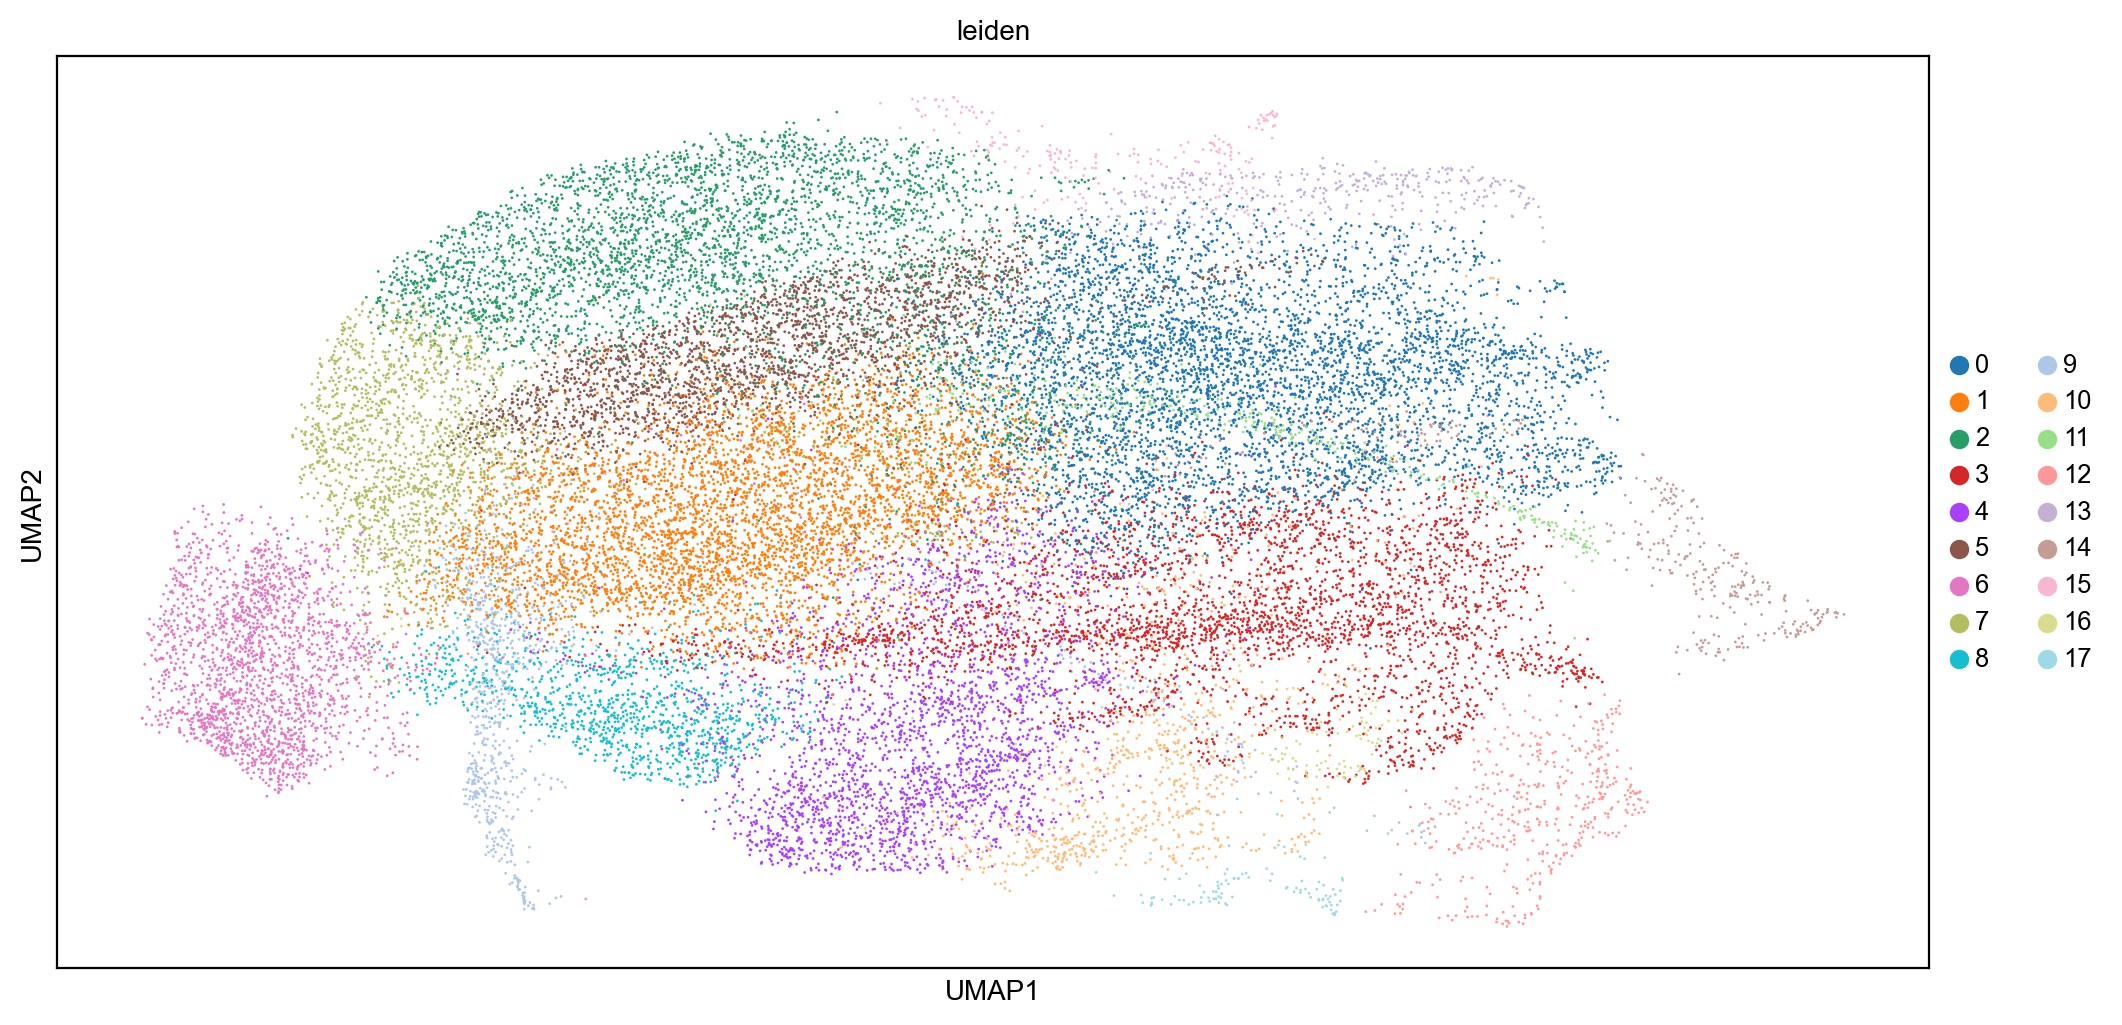

In [42]:
# Helper function
sc.pl.umap(adata, color=['leiden'])

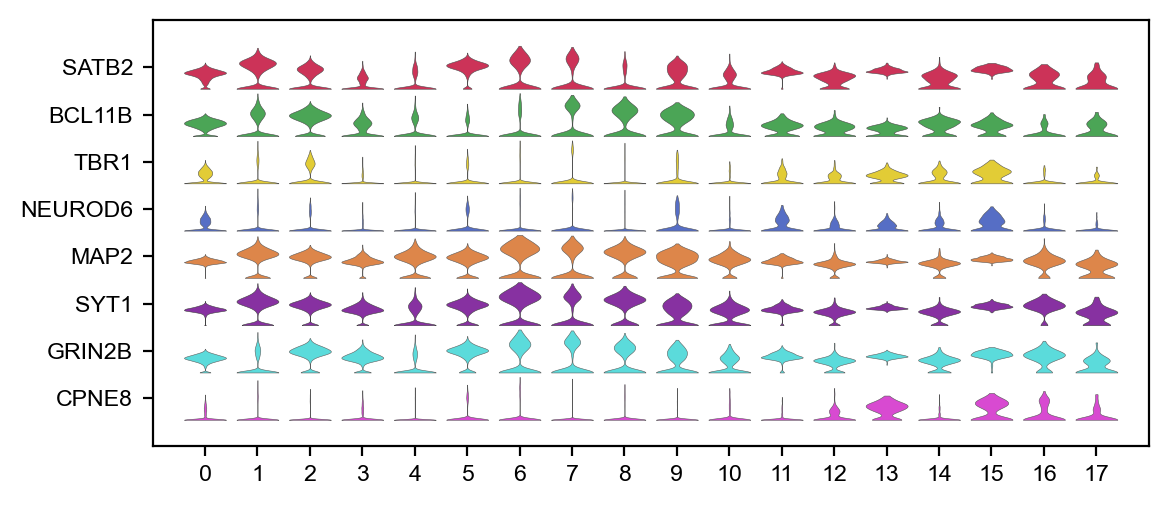

In [ ]:
# Violin plots
sc.pl.stacked_violin(adata, general_genes, groupby="leiden", row_palette=discreet_cols_n23, swap_axes=True)
#sc.pl.violin(adata, 'n_genes_by_counts', jitter=0.4, groupby = 'sample', rotation = 90, size=0)

In [ ]:
# Marker genes

ranking genes
    consider 'leiden' groups:
    with sizes: [5037 4664 3822 3375 2602 2457 2066 1809 1132  926  860  514  452  386
  339  224  133  104]
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:10)


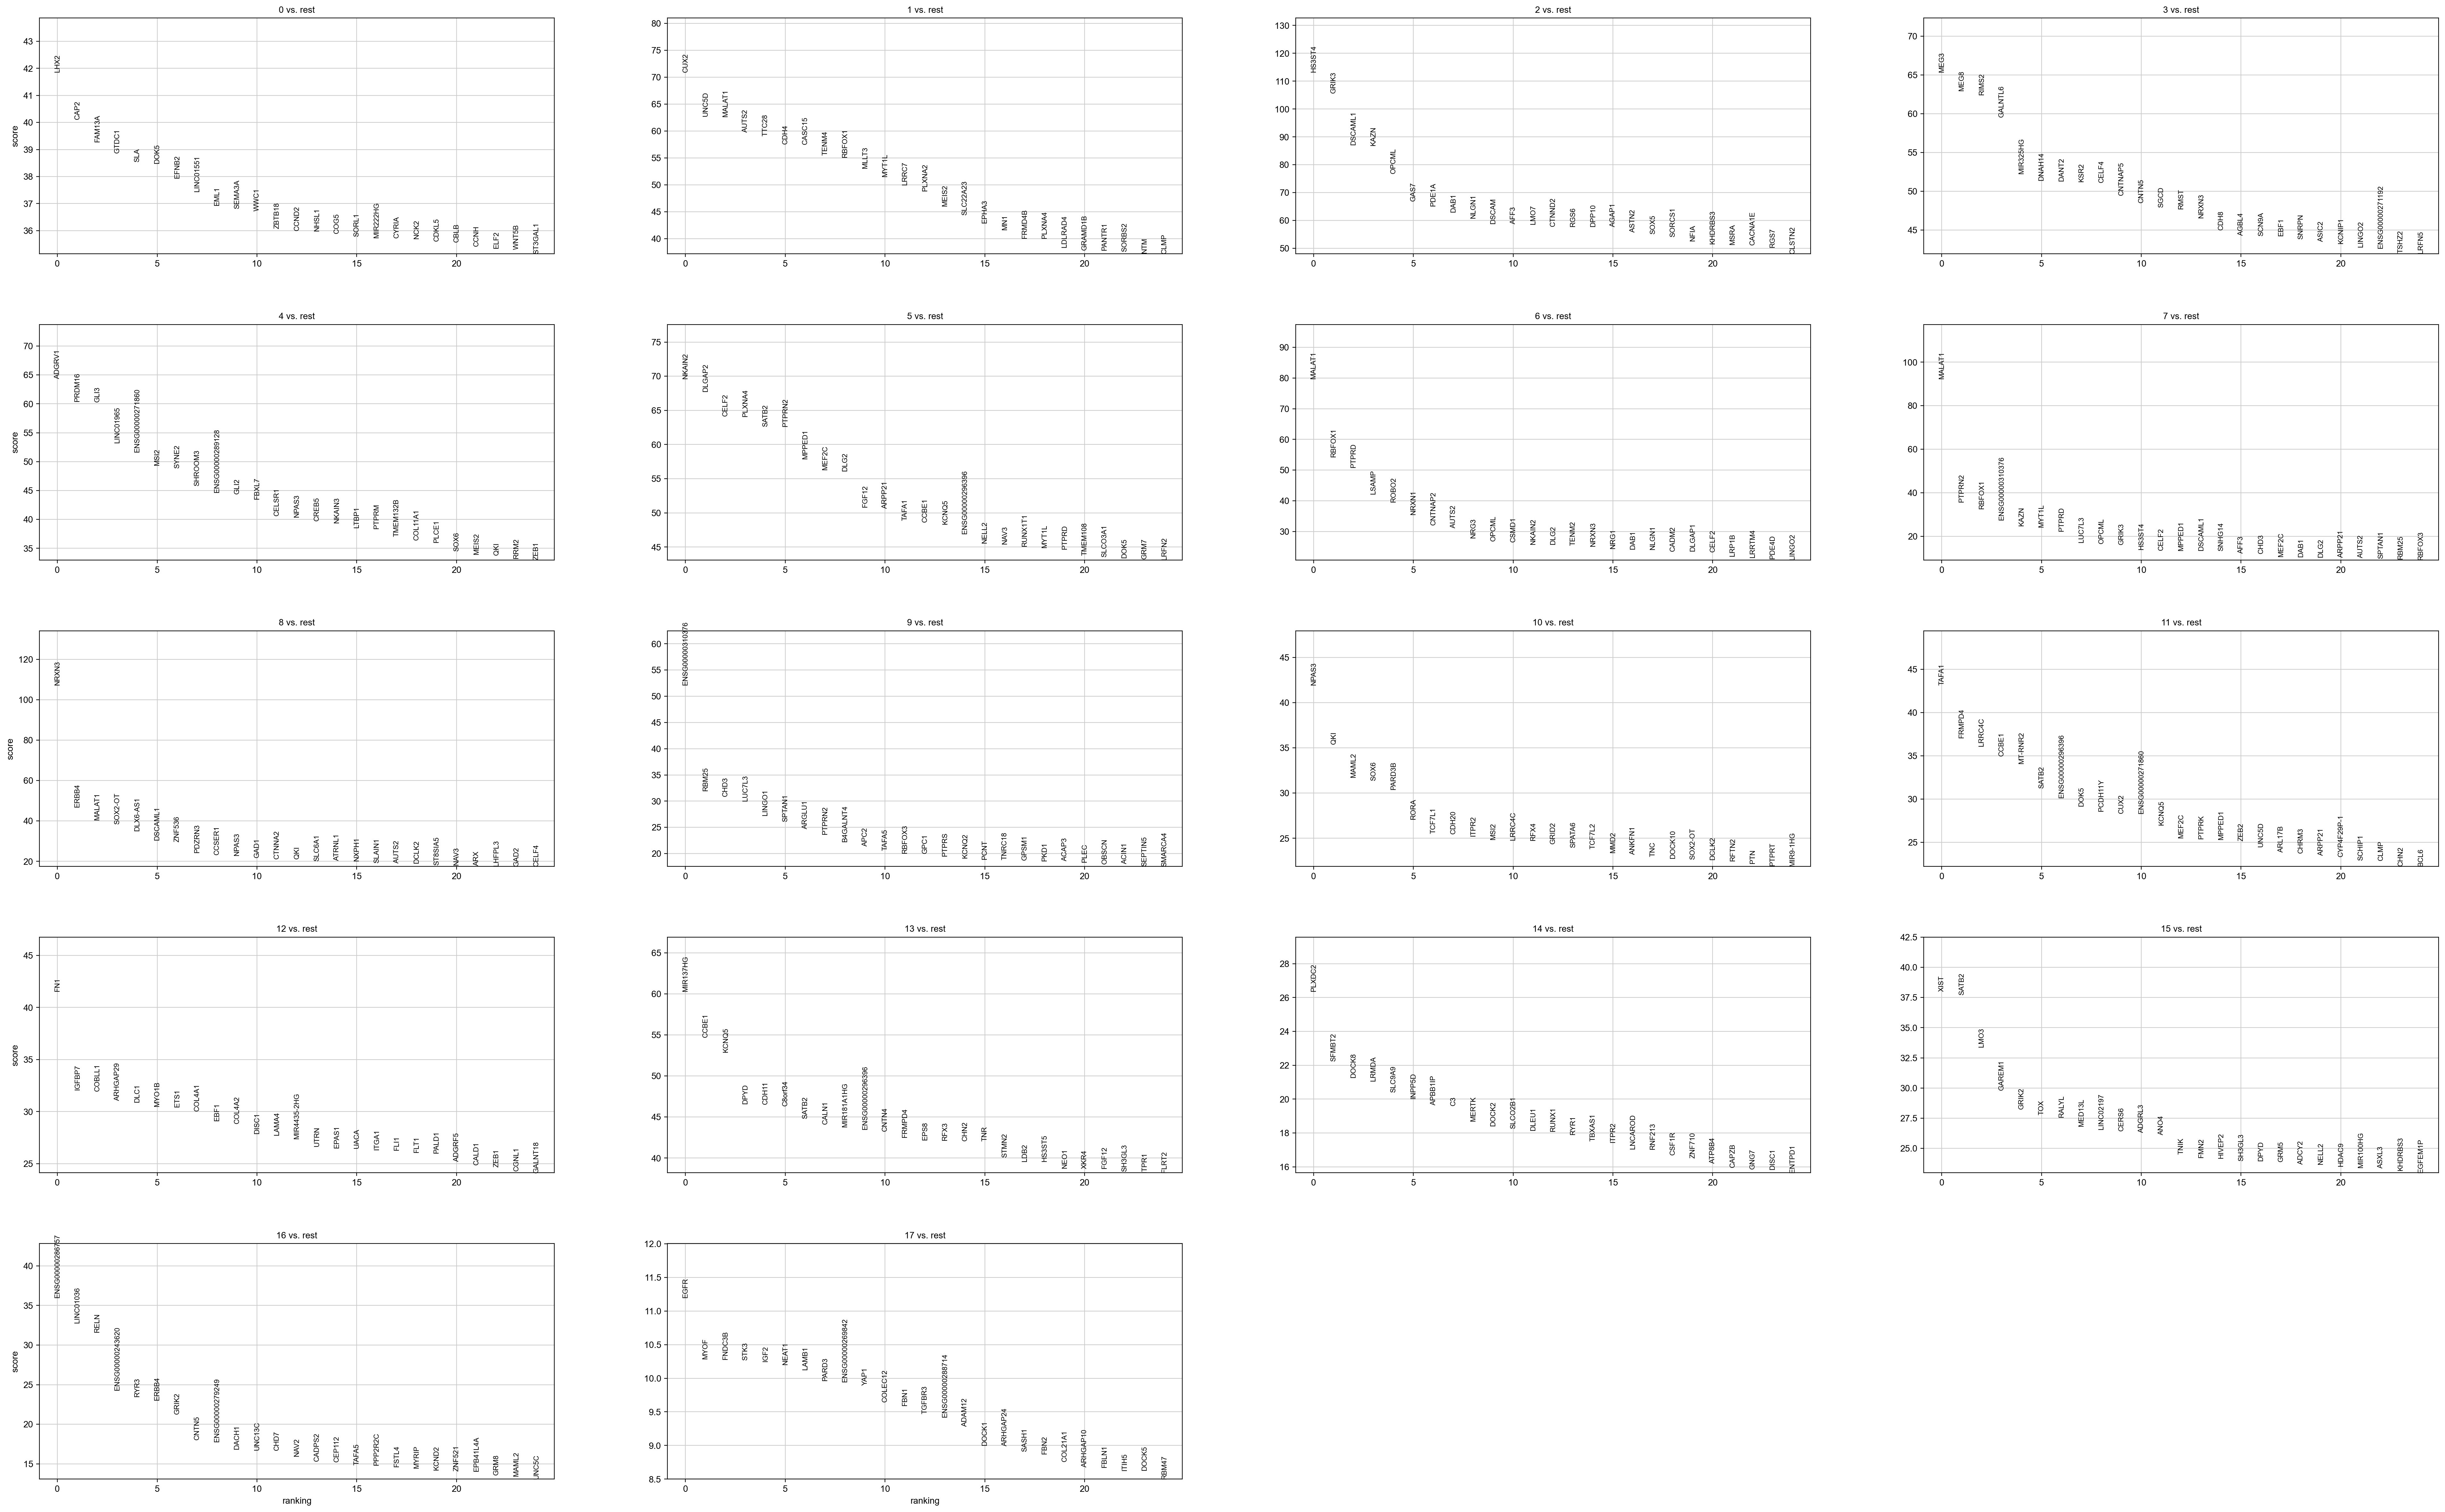

In [45]:
sc.tl.rank_genes_groups(adata, "leiden", method="t-test")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [50]:
adata.uns['rank_genes_groups']
pd.DataFrame(adata.uns["rank_genes_groups"]["names"])

0         1        2         3                4       5       6  \
0        LHX2      CUX2   HS3ST4      MEG3           ADGRV1  NKAIN2  MALAT1   
1        CAP2     UNC5D    GRIK3      MEG8           PRDM16  DLGAP2  RBFOX1   
2      FAM13A    MALAT1  DSCAML1     RIMS2             GLI3   CELF2   PTPRD   
3       GTDC1     AUTS2     KAZN   GALNTL6        LINC01965  PLXNA4   LSAMP   
4         SLA     TTC28    OPCML  MIR325HG  ENSG00000271860   SATB2   ROBO2   
...       ...       ...      ...       ...              ...     ...     ...   
50369  DLGAP1     GRIK3     CDH4    RBFOX1            MYT1L    GLI3  NKAIN1   
50370   PTPRD     NTRK2   PANTR1      SOX5           GABBR2    CHD7   TTYH3   
50371  RBFOX1     MDGA2   PLXNA4    MPPED1          CACNA1E  BCL11B   CLIP2   
50372   AUTS2     PDZD2     RORA     SATB2           ARPP21   GRIK3   ACAP3   
50373  MALAT1  PRICKLE2     CUX2    MALAT1         PRICKLE2   PTPRM    APC2   

                     7         8                9      10               11  \
0               MALAT1     NRXN3  ENSG00000310376   NPAS3            TAFA1   
1               PTPRN2     ERBB4            RBM25     QKI           FRMPD4   
2               RBFOX1    MALAT1             CHD3   MAML2           LRRC4C   
3      ENSG00000310376   SOX2-OT           LUC7L3    SOX6            CCBE1   
4                 KAZN  DLX6-AS1           LINGO1  PARD3B          MT-RNR2   
...                ...       ...              ...     ...              ...   
50369             SOX6     CDHR3             PKIA   MEF2C  ENSG00000310376   
50370  ENSG00000294080   TMEM163            THAP5  RBFOX1  ENSG00000290690   
50371           ZBTB20       SLA  ENSG00000296732  RBFOX3            AUTS2   
50372          SLC17A6     EMID1  ENSG00000291243   MYT1L             XIST   
50373  ENSG00000236141    SCUBE1              EMB  MPPED1           MALAT1   

             12        13      14               15               16  \
0           FN1  MIR137HG  PLXDC2             XIST  ENSG00000286757   
1        IGFBP7     CCBE1  SFMBT2            SATB2        LINC01036   
2        COBLL1     KCNQ5   DOCK8             LMO3             RELN   
3      ARHGAP29      DPYD   LRMDA           GAREM1  ENSG00000243620   
4          DLC1     CDH11  SLC9A9            GRIK2             RYR3   
...         ...       ...     ...              ...              ...   
50369    DLGAP1    RBFOX1   NRXN1  ENSG00000310376  ENSG00000294948   
50370     PTPRD      XIST   AUTS2           ANOS2P  ENSG00000279954   
50371     AUTS2     AUTS2  RBFOX1            USP9Y             KIF6   
50372    RBFOX1    LUC7L3   PTPRD            KDM5D          RAPGEF3   
50373    MALAT1    MALAT1  MALAT1  ENSG00000295056           GRM5P1   

               17  
0            EGFR  
1            MYOF  
2          FNDC3B  
3            STK3  
4            IGF2  
...           ...  
50369  PABPC5-AS1  
50370      TXNL4B  
50371       PWAR1  
50372     TMEM198  
50373   LINC02687  

[50374 rows x 18 columns]

In [73]:
mad_threshold

np.float64(10809.635203956408)